# 5.2.3 过程测量与个体差异

## 学习目标与先修知识

能辨认三类变异进入模型（model）的位置；推导独立扰动下的状态（state）与观测（observation）方差（variance），限定方差极限（limit）和经验分位带的含义。

先修：5.2.1—5.2.2；递推、几何和与第 3 篇的状态和观测。 [复习上一节](02-联合变化与协方差.ipynb)。

## 具体问题

同样是曲线有差异，原因可能是每一步真的受到扰动、仪器读数有误差，或不同个体具有固定参数（parameter）。可以设计什么对照，把三种机制分开？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
P=0.0
rows=[]
for n in range(3):
    rows.append((n,P,P+.09));P=.8**2*P+.04
display(Markdown(show_table(['步 n','状态方差 / U²','观测方差 / U²'],rows)))

| 步 n | 状态方差 / U² | 观测方差 / U² |
| --- | --- | --- |
| 0 | 0 | 0.09 |
| 1 | 0.04 | 0.13 |
| 2 | 0.0656 | 0.1556 |

## 模型假设

x 是相对参考水平的偏差，允许负值；x[n+1]=a*x[n]+w[n]，y[n]=x[n]+v[n]，a=0.8，时间步为一个观察周期。w、v 零均值，分别为独立高斯过程扰动和测量误差，方差 Q=0.04、R=0.09 U²；无观测反馈（feedback）。随机路径从 x0=0、P0=0 开始。根种子 5203，200 个子流各生成一条长 30 步路径。右图的固定个体参数对照单独从共同偏差 x0=1 U 开始，关闭所有扰动，a 使用教学值 0.6、0.9。

## 数学解释与推导

取期望（expectation）得 μ[n+1]=aμ[n]。将状态中心化后平方，
$$P_{n+1}=a^2P_n+Q+2a\operatorname{Cov}(x_n,w_n).$$
本节独立性使最后一项为零。观测同理有 Var(y[n])=P[n]+R；R 不进入下一次状态方差，因为模型没有把观测回送。

反复代入可得到独立的闭式参照：$P_n=a^{2n}P_0+Q\sum_{j=0}^{n-1}a^{2j}$。当 |a|<1 时趋向 Q/(1−a²)；当 |a|=1 且 Q>0 时线性增长；|a|>1 通常放大扰动。这里的 a 作用于有正负的偏差，不能把条件简写为 a<1。Q=0、P0=0 是始终零方差的特例。

固定个体参数 aᵢ 生成 xᵢ[n]=aᵢⁿx0；同一个体的 aᵢ 不随时刻重抽。群体差异不等于每步独立过程噪声（process noise）。对 200 条随机轨迹（trajectory）逐时刻取分位数，得到的是该时刻状态的经验分布（distribution）摘要；它既不是 a 的置信区间（confidence interval），也不保证同一条轨迹全程有 90% 概率（probability）落在带内。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def variance_path(a, process_variance, initial_variance, steps):
    values = [initial_variance]
    for _ in range(steps):
        values.append(a*a*values[-1]+process_variance)
    return values


def observed_variances(a, process_variance, measurement_variance, initial_variance, steps):
    state = variance_path(a,process_variance,initial_variance,steps)
    return state, [p+measurement_variance for p in state]

## 对照实验

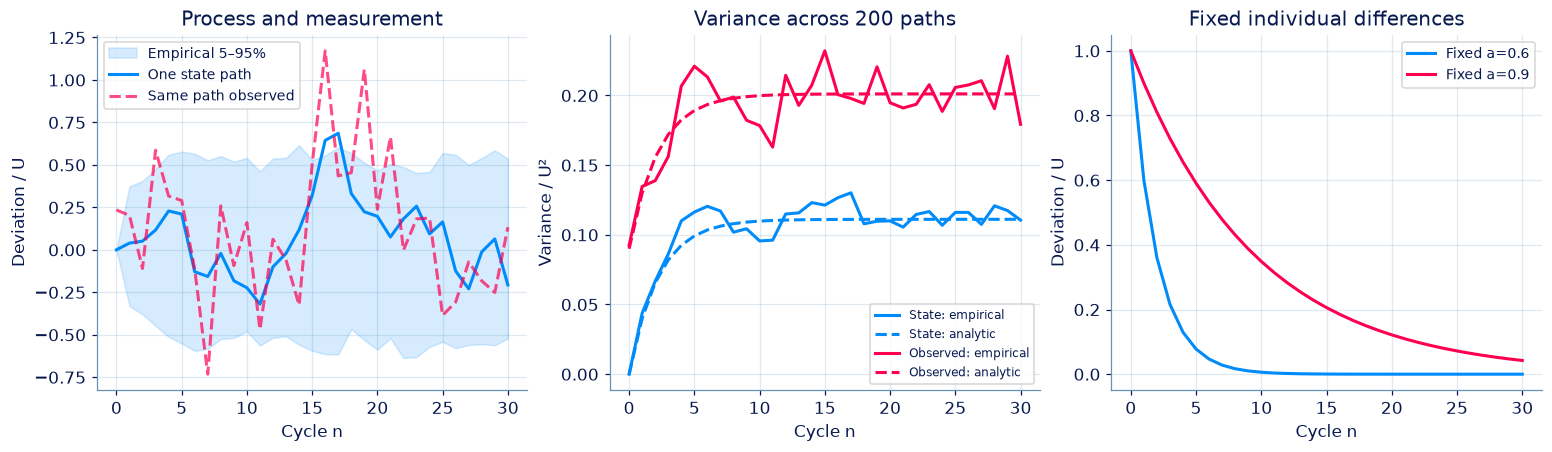

| 终点统计 | 经验 / U² | 理论 / U² |
| --- | --- | --- |
| 状态方差 | 0.110534 | 0.111111 |
| 观测方差 | 0.179288 | 0.201111 |

根种子 5203 ；独立路径数 200 ；PCG64；NumPy 2.5.3


In [4]:
a=.8;Q=.04;R=.09;steps=30;repeats=200;root_seed=5203
streams=np.random.SeedSequence(root_seed).spawn(repeats)
states=np.zeros((repeats,steps+1));observed=np.zeros_like(states)
for b,seed in enumerate(streams):
    rng=np.random.Generator(np.random.PCG64(seed))
    w=rng.normal(0,np.sqrt(Q),steps);v=rng.normal(0,np.sqrt(R),steps+1)
    for n in range(steps):states[b,n+1]=a*states[b,n]+w[n]
    observed[b]=states[b]+v
theory,observation_theory=observed_variances(a,Q,R,0,steps)
fig,axes=plt.subplots(1,3,figsize=(14,4));n=np.arange(steps+1)
lo,hi=np.quantile(states,[.05,.95],axis=0)
axes[0].fill_between(n,lo,hi,color=BLUE,alpha=.16,label='Empirical 5–95%')
axes[0].plot(n,states[0],color=BLUE,label='One state path');axes[0].plot(n,observed[0],color=PINK,ls='--',alpha=.7,label='Same path observed')
axes[0].set(xlabel='Cycle n',ylabel='Deviation / U',title='Process and measurement');axes[0].legend(fontsize=9)
axes[1].plot(n,states.var(axis=0,ddof=1),color=BLUE,label='State: empirical');axes[1].plot(n,theory,color=BLUE,ls='--',label='State: analytic')
axes[1].plot(n,observed.var(axis=0,ddof=1),color=PINK,label='Observed: empirical');axes[1].plot(n,observation_theory,color=PINK,ls='--',label='Observed: analytic')
axes[1].set(xlabel='Cycle n',ylabel='Variance / U²',title='Variance across 200 paths');axes[1].legend(fontsize=8)
for factor,color in [(.6,BLUE),(.9,PINK)]:axes[2].plot(n,factor**n,color=color,label=f'Fixed a={factor}')
axes[2].set(xlabel='Cycle n',ylabel='Deviation / U',title='Fixed individual differences');axes[2].legend(fontsize=9)
plt.show()
display(Markdown(show_table(['终点统计','经验 / U²','理论 / U²'],[['状态方差',states[:,-1].var(ddof=1),theory[-1]],['观测方差',observed[:,-1].var(ddof=1),observation_theory[-1]]])))
print('根种子',root_seed,'；独立路径数',repeats,'；PCG64；NumPy',np.__version__)

## 结果解释

测量噪声（measurement noise）使同一状态轨迹的读数更散，却不会在本模型中反过来驱动状态。蓝带来自许多路径，蓝实线只是其中一条。右图没有随机扰动；它展示仅由固定参数造成的差异。

### 独立核对

递推与有限几何和走不同计算路径；终点的高斯方差给出重复误差尺度，不要求所有相关时刻分别满足独立检验。

In [5]:
closed=[Q*sum(a**(2*j) for j in range(n)) for n in range(steps+1)]
np.testing.assert_allclose(theory,closed,atol=1e-12)
np.testing.assert_allclose(theory[:3],[0,.04,.0656])
for arr,p in [(states,theory[-1]),(observed,observation_theory[-1])]:
    assert abs(arr[:,-1].var(ddof=1)-p)<5*p*np.sqrt(2/(repeats-1))
assert variance_path(-1,.04,0,2)==[0,.04,.08]
print('几何和、前两步、负倍数边界和重复终点方差核对通过。')

几何和、前两步、负倍数边界和重复终点方差核对通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-02-期望、方差、协方差与噪声/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：过程扰动怎样逐步积累

x[n+1]=a*x[n]+w[n]。w 与当前状态（state）独立、零均值，方差（variance）为 Q。计算状态方差，包含起点。

**函数与代码模板**

```python
def solve(
    a: float,
    process_variance: float,
    initial_variance: float,
    steps: int,
) -> list[float]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 每步状态偏差的倍数。 | 1 |
| `process_variance` | `float` | 独立过程扰动方差 Q。 | U² |
| `initial_variance` | `float` | 起始状态偏差方差 P0。 | U² |
| `steps` | `int` | 更新步数。 | 步 |

**返回值**

直接返回 variances（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `variances` | `list[float]` | 长度 steps+1 的状态方差。 | U² |

**计算规则**

P[0]=initial_variance；P[n+1]=a²P[n]+process_variance。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- −1≤a≤1；0≤process_variance,initial_variance≤10；0≤steps≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 每步状态偏差的倍数。 | 0.8 | 1 |
| process_variance | 独立过程扰动方差 Q。 | 0.04 | U² |
| initial_variance | 起始状态偏差方差 P0。 | 0 | U² |
| steps | 更新步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.8
process_variance = 0.04
initial_variance = 0
steps = 2

result = solve(a, process_variance, initial_variance, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| variances | 长度 steps+1 的状态方差。 | [0, 0.04, 0.0656] | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0, 0.04, 0.0656]
```

**样例解释**

依次为 [0,0.04,0.0656] U²；第二步保留 0.8²×0.04，再加入 0.04。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：过程扰动怎样逐步积累](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-variance-path)

### 第 2 题 · 多项选择题：哪一种噪声会进入未来状态

x[n+1]=a*x[n]+w[n]，y[n]=x[n]+v[n]，无基于 y 的反馈（feedback）。哪些正确？

- **A.** 给每个个体固定不同的 a，等同于每步重抽 w[n]。
- **B.** 若 v 与 x 独立，则 Var(y)=Var(x)+Var(v)。
- **C.** w[n] 影响 x[n+1]，并可继续传播。
- **D.** v[n] 改变本次观测（observation），但不直接进入下一状态（state）。

[作答：哪一种噪声会进入未来状态](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-noise-location)

### 第 3 题 · 多项选择题：方差极限的条件

零均值独立扰动方差（variance） Q>0，P[n+1]=a²P[n]+Q。哪些正确？

- **A.** 方差存在有限极限（limit）就保证每条轨迹（trajectory）变成常数。
- **B.** |a|<1 时极限为 Q/(1−a²)。
- **C.** a=1 时方差每步增加 Q。
- **D.** a=−2 因为 a<1，所以方差收敛。

[作答：方差极限的条件](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-stationary-variance)

### 第 4 题 · 单项选择题：固定个体差异与过程噪声

两群个体均从 x0=1 U 出发，各个体参数（parameter） a 在实验期间固定为 0.6 或 0.9，之后 x[n+1]=a*x[n]，没有 w 或 v。哪项正确？

- **A.** 同群个体必定每步随机跳动。
- **B.** 不同轨迹（trajectory）可以完全来自固定个体参数差异。
- **C.** 观测（observation）差异证明存在过程噪声（process noise）。
- **D.** 每一步都重新抽 a 才是题设。

[作答：固定个体差异与过程噪声](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-individual-fixed)

### 第 5 题 · 单项选择题：样本带与参数区间

展示 200 条状态（state）路径每个时刻的 5%—95% 经验分位带。哪项正确？

- **A.** 它描述逐时刻状态的经验分布（distribution），不能自动解释成未知 a 的区间。
- **B.** 它保证每条路径全程有 90% 概率（probability）在带内。
- **C.** 它是数学证明，不受样本数影响。
- **D.** 带内包含全部路径。

[作答：样本带与参数区间](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-quantiles)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 10—11 讲：独立性和协方差；本节方差递推在正文展开。